# Import Required Libraries

Import PyTorch and its neural network module.

In [10]:
import torch
import torch.nn as nn

# Define the LeNet-5 Model Class

Create a class that inherits from nn.Module and defines the LeNet-5 architecture with convolutional and fully connected layers.

In [11]:
class LeNet5(nn.Module):
    """
    Implementation of the classic LeNet-5 convolutional neural network.

    Architecture overview:
    - Input: grayscale image (1 channel), typically 32x32
    - Conv1 -> ReLU -> AvgPool
    - Conv2 -> ReLU -> AvgPool
    - Conv3 -> ReLU
    - Fully connected (FC1) -> ReLU
    - Fully connected (FC2) -> output logits (10 classes)

    Commonly used for digit classification (e.g., MNIST).
    """

    def __init__(self):
        """
        Initialize all layers of the network.
        """
        super(LeNet5, self).__init__()

        # First convolutional layer:
        # Input: 1 channel (grayscale), Output: 6 feature maps
        # Kernel size: 5x5
        # Stride = how many pixels the filter jumps each step.
        # Padding = adding pixels (usually zeros) around the input.
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)

        # Average pooling layer:
        # Reduces spatial dimensions by factor of 2
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional layer:
        # Input: 6 channels, Output: 16 feature maps
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)

        # Third convolutional layer:
        # Input: 16 channels, Output: 120 feature maps
        # This effectively prepares data for the fully connected layers
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)

        # First fully connected layer:
        # Input features: 120, Output: 84
        self.fc1 = nn.Linear(120, 84)

        # Final fully connected layer:
        # Output: 10 classes (e.g., digits 0–9)
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        """
        Define the forward pass of the network.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, 1, H, W)

        Returns:
            torch.Tensor: Output logits of shape (batch_size, 10)
        """

        # First block: Conv1 -> ReLU -> Pool
        x = self.pool(torch.relu(self.conv1(x)))

        # Second block: Conv2 -> ReLU -> Pool
        x = self.pool(torch.relu(self.conv2(x)))

        # Third convolution + activation
        x = torch.relu(self.conv3(x))

        # Flatten tensor for fully connected layers
        # -1 means infer batch size automatically
        x = x.view(-1, 120)

        # First fully connected layer + activation
        x = torch.relu(self.fc1(x))

        # Final layer (no activation here, since logits are expected)
        x = self.fc2(x)

        return x

# Instantiate the Model

Create an instance of the LeNet-5 model.

In [12]:
model = LeNet5()
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)


# Visualize Conv1 filters (before training)

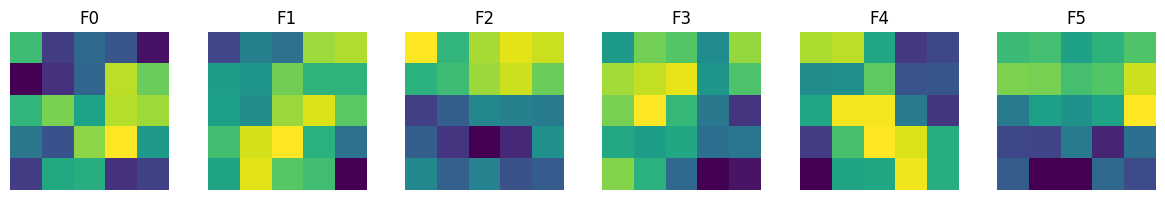

In [16]:
import matplotlib.pyplot as plt

def show_conv1_filters(model):
    """
    Displays the filters of the first convolutional layer.
    Should be called BEFORE training to see initial state.
    """
    # Get weights: shape (out_channels, in_channels, H, W)
    weights = model.conv1.weight.data.clone()

    # Normalize weights for visualization (0–1 range)
    weights = (weights - weights.min()) / (weights.max() - weights.min())

    num_filters = weights.shape[0]

    fig, axes = plt.subplots(1, num_filters, figsize=(num_filters * 2, 2))

    for i in range(num_filters):
        # Since input is grayscale, we take channel 0
        filter_img = weights[i, 0].cpu().numpy()

        axes[i].imshow(filter_img)
        axes[i].axis('off')
        axes[i].set_title(f'F{i}')

    plt.tight_layout()
    plt.show()


# Usage
show_conv1_filters(model)

# Load MNIST + Show examples

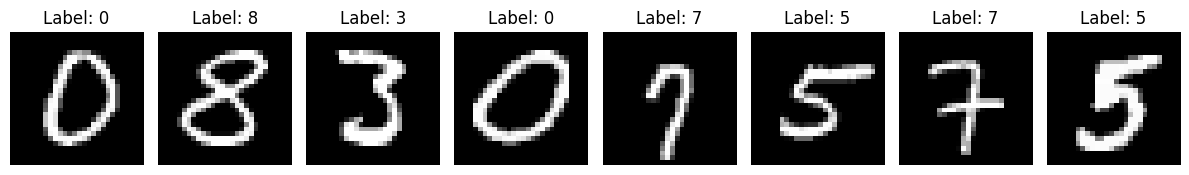

In [14]:
from torchvision import datasets, transforms

# Transform: convert images to tensor
transform = transforms.ToTensor()

# Load MNIST dataset (downloads automatically if not present)
mnist = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Create a DataLoader
loader = torch.utils.data.DataLoader(mnist, batch_size=8, shuffle=True)

# Get one batch
images, labels = next(iter(loader))

# Plot images
fig, axes = plt.subplots(1, 8, figsize=(12, 2))

for i in range(8):
    img = images[i].squeeze()  # remove channel dimension (1, 28, 28) → (28, 28)
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Full training example (PyTorch)
#### MNIST Training Pipeline (LeNet-5)

<small style="font-size: 0.5em;">

⚙️ 1. Input Preparation
- Dataset: MNIST (handwritten digits)
  - Original size: 28×28
  - Resized to: 32×32 (to match LeNet-5)
- Converted to tensors for PyTorch

🧠 2. Model (LeNet-5)
Architecture:

> Conv → ReLU → Pool → Conv → ReLU → Pool → Conv → FC → FC

- Learns hierarchical features:
- Edges → Shapes → Digits

📉 3. Loss Function
- `CrossEntropyLoss` Compares:
  - Predicted logits
  - True labels (0–9)
- Outputs error (how wrong the model is)

🔁 4. Training Loop
For each batch:

> Forward pass → Compute loss → Backpropagation → Update weights

- This is where learning happens

🧪 5. Evaluation
- Switch model to `eval()` mode
- Disable gradient computation
- Measure accuracy on test data

🚀 6. Optimization
- Optimizer: `Adam`
- Updates weights using gradients
- Goal: minimize loss over time

📈 Final Result
- Loss decreases over epochs
- Accuracy increases (≈ 98% on MNIST)
</small>

In [ ]:
import torch.optim as optim

# ----------------------------
# 1. Device (CPU / GPU)
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------
# 2. Transforms (IMPORTANT)
# ----------------------------
# LeNet expects 32x32 → MNIST is 28x28
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

# ----------------------------
# 3. Dataset + DataLoader
# ----------------------------
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# ----------------------------
# 4. Model
# ----------------------------
model = LeNet5().to(device)

# ----------------------------
# 5. Loss + Optimizer
# ----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ----------------------------
# 6. Training loop
# ----------------------------
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")

# ----------------------------
# 7. Evaluation
# ----------------------------
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Epoch [1/5] Loss: 0.2743
Epoch [2/5] Loss: 0.0728
Epoch [3/5] Loss: 0.0537
Epoch [4/5] Loss: 0.0422
Epoch [5/5] Loss: 0.0339
Test Accuracy: 98.90%


# Show misclassified images

<small style="font-size: 0.5em;">

## 🔍 What you’ll see

Each image shows:

**Pred:** X  
**True:** Y  

**Example:**

**Pred:** 5  
**True:** 3  

👉 That tells you exactly how your model is getting confused.

## 🧠 What to look for

You’ll start noticing patterns like:

### 1. Ambiguous handwriting
- 4 that looks like 9  
- 5 that looks like 3  

### 2. Poor contrast / thin strokes
- Hard for filters to detect edges  

### 3. Model bias
- Maybe your model over-predicts certain digits  

</small>

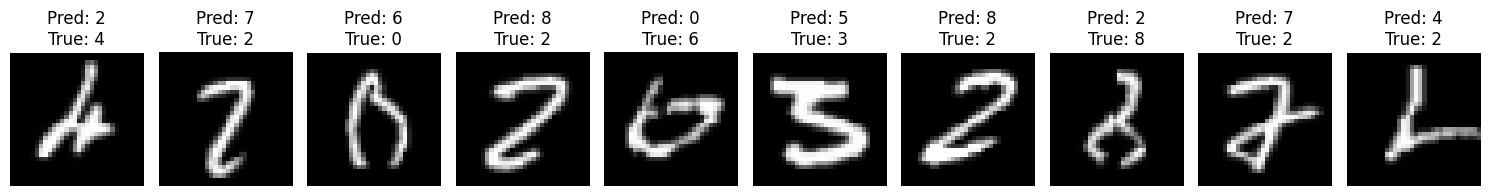

In [21]:
def show_misclassified(model, dataloader, device, max_images=10):
    model.eval()
    
    misclassified_images = []
    misclassified_labels = []
    misclassified_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            # Find wrong predictions
            wrong = preds != labels

            for i in range(len(images)):
                if wrong[i]:
                    misclassified_images.append(images[i].cpu())
                    misclassified_labels.append(labels[i].cpu())
                    misclassified_preds.append(preds[i].cpu())

                if len(misclassified_images) >= max_images:
                    break
            if len(misclassified_images) >= max_images:
                break

    # Plot results
    fig, axes = plt.subplots(1, len(misclassified_images), figsize=(15, 3))

    for i in range(len(misclassified_images)):
        img = misclassified_images[i].squeeze()

        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(
            f"Pred: {misclassified_preds[i].item()}\nTrue: {misclassified_labels[i].item()}"
        )
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


# Call it
show_misclassified(model, test_loader, device, max_images=10)